In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import HashingVectorizer

In [ ]:
df = pd.read_csv('/content/spam.csv', encoding='latin_1')

In [ ]:
df = df.rename(columns={'v2': 'MESSAGE', 'v1': 'Spam'})
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])
df['Spam'] = LabelEncoder().fit_transform(df['Spam'])

In [ ]:
df.head()

,Spam,MESSAGE
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df['Spam'].value_counts()

,count
Spam,
0,4825
1,747


In [ ]:
X = df['MESSAGE']
y = df['Spam']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape

((4457,), (1115,))

Preprocessing

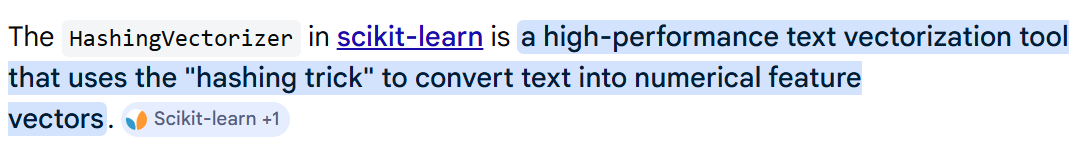

In [ ]:
hashing = HashingVectorizer(n_features=1000, stop_words="english")
X_train = hashing.fit_transform(X_train)
X_test = hashing.fit_transform(X_test)

Creating and training Bernuolly Navie Bayes model

In [131]:
# def evaluate_model(model, features, target, plot_title: str):
#   # Apply prediction from the model
#   pred = model.predict(features)

#   #Print metrics from classification report
#   print(classification_report(target, pred))

#   # Callculate and show confusion Matrix
#   cm = confusion_matrix(target, pred, labels=model.classes_)
#   disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
#   disp.plot()

In [132]:
bnb = BernoulliNB()
bnb.fit(X_train, y_train)
y_predict = bnb.predict(X_test)


In [133]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       965
           1       0.89      0.84      0.87       150

    accuracy                           0.97      1115
   macro avg       0.93      0.91      0.92      1115
weighted avg       0.96      0.97      0.96      1115



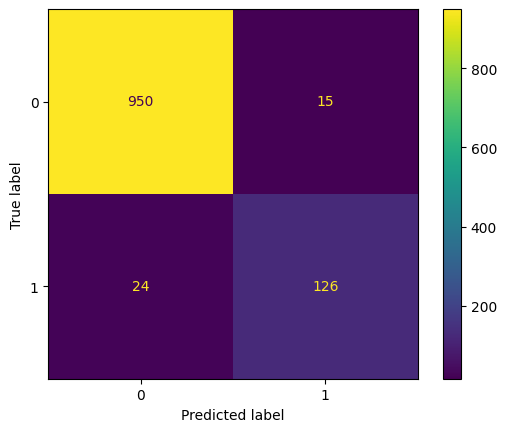

In [134]:
# Callculate and show confusion Matrix
cm = confusion_matrix(y_test, y_predict, labels=bnb.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=bnb.classes_)
disp.plot()